<a href="https://colab.research.google.com/github/xandercook172-del/wre-bookings-dashboard/blob/Colab/FLExtractORL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload dashboard HTML


Saving ALLStateDashWXTRAKPI_full2025_total76562_fixed_withPrice_SAFE.html.html to ALLStateDashWXTRAKPI_full2025_total76562_fixed_withPrice_SAFE.html.html


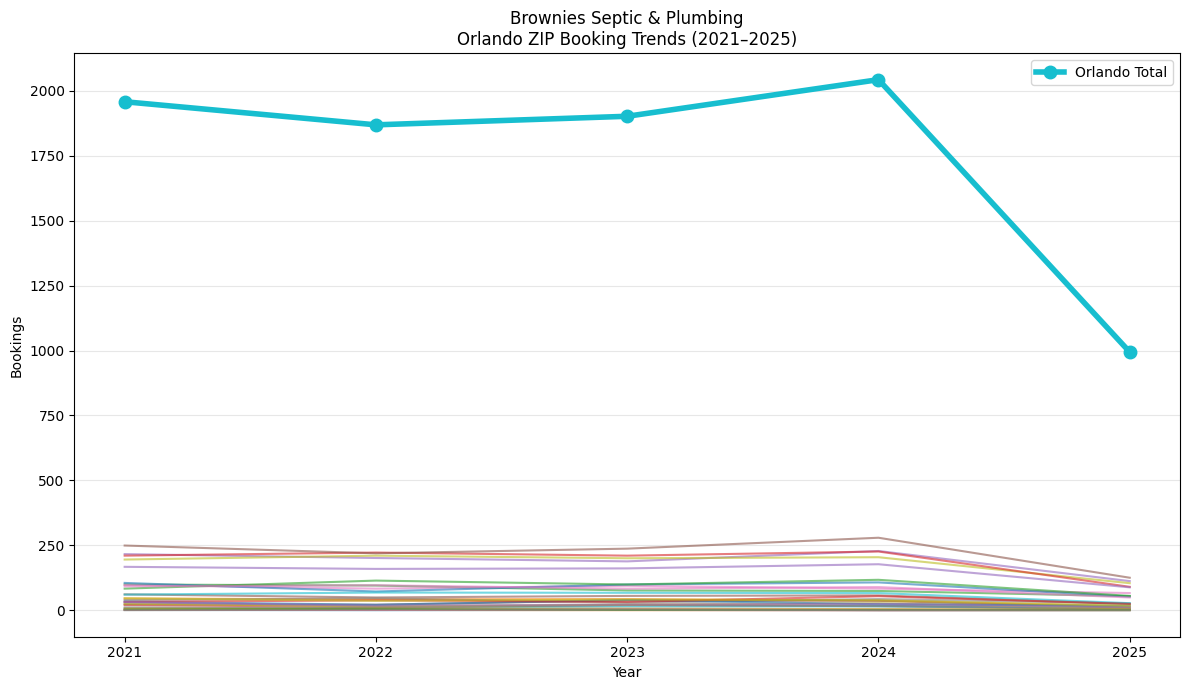

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================
# Brownies Septic & Plumbing
# Orlando ZIP Trends + Orlando Total
# ============================================

!pip -q install openpyxl

import re
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------
# USER INPUTS
# --------------------------------------------
DASHBOARD_HTML_PATH = "/content/dashboard.html"

TARGET_BRAND = "Brownie's Septic & Plumbing"
TARGET_STATE = "FL"
TARGET_CITY = "Orlando"

YEARS = ["2021","2022","2023","2024","2025"]

# --------------------------------------------
# Upload dashboard HTML
# --------------------------------------------
if not os.path.exists(DASHBOARD_HTML_PATH):
    print("Upload dashboard HTML")
    uploaded = files.upload()
    name = next(iter(uploaded.keys()))
    DASHBOARD_HTML_PATH = "/content/" + name

# --------------------------------------------
# Extract rawData
# --------------------------------------------
html = Path(DASHBOARD_HTML_PATH).read_text(encoding="utf-8", errors="ignore")

m = re.search(r"(?:const|var)\s+rawData\s*=\s*(\[\s*.*?\s*\]);", html, flags=re.S)

if not m:
    raise ValueError("rawData not found")

raw = json.loads(m.group(1))
df = pd.DataFrame(raw)

# --------------------------------------------
# Clean fields
# --------------------------------------------
df["Brand"] = df.get("Brand","").astype(str).str.strip()
df["state_id"] = df.get("state_id","").astype(str).str.strip()
df["city"] = df.get("city","").astype(str).str.strip()

df["zip"] = (
    df.get("zip","")
    .astype(str)
    .str.replace(r"\D","",regex=True)
    .str.zfill(5)
)

for y in YEARS:
    df[y] = pd.to_numeric(df.get(y,0), errors="coerce").fillna(0)

# --------------------------------------------
# Filter Orlando rows
# --------------------------------------------
dff = df[
    (df["Brand"] == TARGET_BRAND) &
    (df["state_id"] == TARGET_STATE) &
    (df["city"].str.lower() == TARGET_CITY.lower())
].copy()

# --------------------------------------------
# Aggregate bookings by ZIP
# --------------------------------------------
zip_trend = (
    dff.groupby("zip")[YEARS]
    .sum()
    .reset_index()
)

# --------------------------------------------
# Calculate Orlando TOTAL
# --------------------------------------------
orlando_total = [int(zip_trend[y].sum()) for y in YEARS]

# --------------------------------------------
# Create chart
# --------------------------------------------
plt.figure(figsize=(12,7))

# Individual ZIP lines
for _, row in zip_trend.iterrows():
    plt.plot(
        YEARS,
        [row[y] for y in YEARS],
        linewidth=1.5,
        alpha=0.6
    )

# Orlando TOTAL line
plt.plot(
    YEARS,
    orlando_total,
    linewidth=4,
    marker="o",
    markersize=9,
    label="Orlando Total"
)

plt.title("Brownies Septic & Plumbing\nOrlando ZIP Booking Trends (2021–2025)")
plt.xlabel("Year")
plt.ylabel("Bookings")
plt.grid(True, axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

chart_path = "/content/orlando_zip_trends_total.png"
plt.savefig(chart_path, dpi=300)

plt.show()

# --------------------------------------------
# Download chart
# --------------------------------------------
files.download(chart_path)